# Consensus Phylogenetic Profile Analysis - Synthetic Demo

**Synthetic data demonstration only**

This notebook demonstrates a computational framework for building consensus phylogenetic profiles, comparing multiple statistical consensus methods, and identifying co-evolving genes using fully synthetic data.


## 1. Setup and Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import trim_mean, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Set random seed for reproducibility
np.random.seed(42)


## 2. Synthetic Data Generation

Generate a full synthetic NPP matrix (20,000 genes × 1,900 species) with structured patterns to mimic evolutionary signal.


In [2]:
print("Generating synthetic NPP matrix...")

N_GENES = 20000
N_SPECIES = 1900

# Create synthetic gene and species names
gene_names = [f"GENE_{i:05d}" for i in range(1, N_GENES + 1)]
species_names = [f"SPECIES_{i:05d}" for i in range(1, N_SPECIES + 1)]

# Generate base matrix with structured patterns
# Strategy: Create blocks of correlated genes to mimic functional modules
n_blocks = 50  # Number of functional blocks
genes_per_block = N_GENES // n_blocks

full_matrix = np.zeros((N_GENES, N_SPECIES))

for block_idx in range(n_blocks):
    start_gene = block_idx * genes_per_block
    end_gene = min((block_idx + 1) * genes_per_block, N_GENES)

    # Create a base pattern for this block
    base_pattern = np.random.randn(N_SPECIES) * 2

    # Add some phylogenetic structure (clustered species similarity)
    cluster_size = N_SPECIES // 10
    for cluster in range(10):
        cluster_start = cluster * cluster_size
        cluster_end = min((cluster + 1) * cluster_size, N_SPECIES)
        base_pattern[cluster_start:cluster_end] += np.random.randn() * 1.5

    # Generate genes in this block with correlation to base pattern
    for gene_idx in range(start_gene, end_gene):
        correlation_strength = 0.3 + np.random.rand() * 0.5  # 0.3 to 0.8
        gene_profile = base_pattern * correlation_strength + np.random.randn(N_SPECIES) * (1 - correlation_strength)
        full_matrix[gene_idx, :] = gene_profile

# Add global noise
full_matrix += np.random.randn(N_GENES, N_SPECIES) * 0.5

# Create DataFrame
df_full_matrix = pd.DataFrame(full_matrix, index=gene_names, columns=species_names)

print(f"Generated full matrix: {df_full_matrix.shape}")
print(f"Matrix statistics:")
print(f"  Mean: {df_full_matrix.values.mean():.3f}")
print(f"  Std: {df_full_matrix.values.std():.3f}")
print(f"  Min: {df_full_matrix.values.min():.3f}")
print(f"  Max: {df_full_matrix.values.max():.3f}")


Generating synthetic NPP matrix...
Generated full matrix: (20000, 1900)
Matrix statistics:
  Mean: 0.020
  Std: 1.609
  Min: -9.292
  Max: 10.527


## 3. Species Subset Selection

In the real analysis, the species subset is determined using a phylogenetic heatmap. Here, we simulate this by generating synthetic similarity scores and selecting the top 400 species that form a coherent cluster.


In [3]:
print("Selecting species subset...")

N_SUBSET_SPECIES = 400

# Simulate phylogenetic similarity scores
# Create a synthetic similarity matrix based on species proximity
# Species that are "close" in the matrix should have higher similarity

# Generate synthetic similarity scores (mimicking phylogenetic distance)
species_similarity_scores = np.zeros(N_SPECIES)

# Create clusters of similar species
n_clusters = 8
cluster_size = N_SPECIES // n_clusters

for cluster_idx in range(n_clusters):
    cluster_start = cluster_idx * cluster_size
    cluster_end = min((cluster_idx + 1) * cluster_size, N_SPECIES)

    # Assign high similarity scores to species in this cluster
    base_score = 0.5 + np.random.rand() * 0.4  # 0.5 to 0.9
    species_similarity_scores[cluster_start:cluster_end] = base_score + np.random.randn(cluster_end - cluster_start) * 0.1

# Select the top N_SUBSET_SPECIES species based on similarity scores
# This mimics selecting a coherent phylogenetic cluster
top_species_indices = np.argsort(species_similarity_scores)[-N_SUBSET_SPECIES:]
selected_species = [species_names[i] for i in sorted(top_species_indices)]

print(f"Selected {len(selected_species)} species for subset analysis")
print(f"Species indices range: {min(top_species_indices)} to {max(top_species_indices)}")


Selecting species subset...
Selected 400 species for subset analysis
Species indices range: 0 to 1893


## 4. Synthetic Segment Extraction

Extract a 7-gene segment from the full matrix, restricted to the selected species subset. This acts as the synthetic "barcode" used to build consensus profiles.


In [4]:
print("Extracting synthetic segment...")

N_SEGMENT_GENES = 7

# Select 7 genes from a coherent block (to ensure they have some correlation)
# Choose from the middle of a block to get genes with good signal
block_idx = n_blocks // 2  # Middle block
start_gene_idx = block_idx * genes_per_block + genes_per_block // 2
segment_gene_indices = list(range(start_gene_idx, start_gene_idx + N_SEGMENT_GENES))
segment_gene_names = [gene_names[i] for i in segment_gene_indices]

# Extract the segment: 7 genes × 400 species
df_segment = df_full_matrix.loc[segment_gene_names, selected_species].copy()

print(f"Extracted segment: {df_segment.shape}")
print(f"Segment genes: {segment_gene_names}")
print(f"\nSegment statistics:")
print(df_segment.describe())


Extracting synthetic segment...
Extracted segment: (7, 400)
Segment genes: ['GENE_10201', 'GENE_10202', 'GENE_10203', 'GENE_10204', 'GENE_10205', 'GENE_10206', 'GENE_10207']

Segment statistics:
       SPECIES_00001  SPECIES_00003  SPECIES_00009  SPECIES_00010  \
count       7.000000       7.000000       7.000000       7.000000   
mean        0.724458       0.585878      -0.413290       0.526667   
std         0.664132       0.605992       1.164908       0.618759   
min        -0.376433      -0.158035      -1.969624      -0.221005   
25%         0.359714       0.140447      -1.410431       0.165157   
50%         0.978658       0.481716       0.099535       0.394558   
75%         1.210544       0.980463       0.451039       0.796808   
max         1.328465       1.535648       0.895841       1.589182   

       SPECIES_00011  SPECIES_00012  SPECIES_00014  SPECIES_00015  \
count       7.000000       7.000000       7.000000       7.000000   
mean       -1.026773      -0.692709      -1.2

## 5. Consensus Profile Generation

Generate 5 different consensus vectors from the 7-gene segment:
1. **Mean**: Average profile across genes
2. **Median**: Median profile across genes
3. **Trimmed Mean**: Average after removing 1 min and 1 max value per species
4. **Medoid**: The profile of the most "central" gene (based on 1-Pearson distance)
5. **PC1**: First principal component of the 7 gene profiles


In [5]:
print("Generating consensus profiles...")

consensus_vectors = {}

# 5.1 Mean
consensus_vectors['mean'] = df_segment.mean(axis=0)
print("Generated 'mean' consensus vector.")

# 5.2 Median
consensus_vectors['median'] = df_segment.median(axis=0)
print("Generated 'median' consensus vector.")

# 5.3 Trimmed Mean
trim_proportion = 1.0 / N_SEGMENT_GENES  # Remove 1 min and 1 max from 7 values
trimmed_mean_array = trim_mean(df_segment.values, proportiontocut=trim_proportion, axis=0)
consensus_vectors['trimmed_mean'] = pd.Series(trimmed_mean_array, index=df_segment.columns)
print(f"Generated 'trimmed_mean' consensus vector (proportion={trim_proportion:.3f}).")

# 5.4 Medoid
print("Calculating 'medoid' consensus vector...")
# Correlate genes (rows) with each other
corr_matrix = df_segment.T.corr(method='pearson')
dist_matrix = 1 - corr_matrix  # Distance = 1 - correlation
sum_distances = dist_matrix.sum(axis=1)  # Sum of distances for each gene
medoid_gene_name = sum_distances.idxmin()  # Gene with minimum sum of distances
consensus_vectors['medoid'] = df_segment.loc[medoid_gene_name]
print(f"Medoid gene selected: {medoid_gene_name}")

# 5.5 PC1 (Principal Component 1)
print("Calculating 'PC1' consensus vector...")
# Transpose so species are rows and genes are columns
df_segment_T = df_segment.T  # Shape: (400 species, 7 genes)

# Standardize the features (genes)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_segment_T)

# Run PCA
pca = PCA(n_components=1)
principal_components = pca.fit_transform(data_scaled)  # Shape: (400, 1)

# Extract the PC1 vector (the projection)
pc1_vector = principal_components.flatten()
consensus_vectors['pc1'] = pd.Series(pc1_vector, index=df_segment.columns)
print("Generated 'PC1' consensus vector.")
print(f"PC1 Explained Variance: {pca.explained_variance_ratio_[0]:.4f}")

print(f"\nGenerated {len(consensus_vectors)} consensus vectors.")


Generating consensus profiles...
Generated 'mean' consensus vector.
Generated 'median' consensus vector.
Generated 'trimmed_mean' consensus vector (proportion=0.143).
Calculating 'medoid' consensus vector...
Medoid gene selected: GENE_10203
Calculating 'PC1' consensus vector...
Generated 'PC1' consensus vector.
PC1 Explained Variance: 0.7088

Generated 5 consensus vectors.


## 6. Correlation-Based Gene Ranking

For each consensus profile, rank all ~20,000 genes based on correlation (Pearson/Spearman) computed **only over the 400 selected species**.


In [6]:
print("Performing correlation-based gene ranking...")

# Slice the full matrix to the selected species subset
df_target_sliced = df_full_matrix[selected_species].copy()

print(f"Target matrix shape (for correlation): {df_target_sliced.shape}")

correlation_methods = ['pearson', 'spearman']
all_correlations = {}

for cons_name, cons_vector in consensus_vectors.items():
    print(f"\nCalculating correlations for: {cons_name.upper()}")
    all_correlations[cons_name] = {}

    for corr_method in correlation_methods:
        print(f"  ... using {corr_method} correlation")

        # Use .corrwith() for efficient vectorized calculation
        # This correlates the cons_vector (Series) with every row (axis=1) of the DataFrame
        correlations = df_target_sliced.corrwith(cons_vector, axis=1, method=corr_method)

        # Drop any NaN results (e.g., from genes with no variance)
        correlations = correlations.dropna()

        all_correlations[cons_name][corr_method] = correlations

        print(f"  ... computed correlations for {len(correlations)} genes")
        print(f"  ... correlation range: [{correlations.min():.4f}, {correlations.max():.4f}]")

print("\nCorrelation analysis complete.")


Performing correlation-based gene ranking...
Target matrix shape (for correlation): (20000, 400)

Calculating correlations for: MEAN
  ... using pearson correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.3025, 0.9349]
  ... using spearman correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.2934, 0.9356]

Calculating correlations for: MEDIAN
  ... using pearson correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.2982, 0.9251]
  ... using spearman correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.2901, 0.9251]

Calculating correlations for: TRIMMED_MEAN
  ... using pearson correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.3055, 0.9351]
  ... using spearman correlation
  ... computed correlations for 20000 genes
  ... correlation range: [-0.2944, 0.9360]

Calculating correlations for: MEDOID
  ... using pearson correlatio

## 7. Coherence Validation

For each consensus method and correlation type, evaluate top-N lists (e.g., top 50, top 100) by measuring internal pairwise correlations to test whether these synthetic "co-evolving" groups are coherent.


In [7]:
print("Computing coherence validation...")

TOP_N_LIST = [50, 100, 200]  # Different top-N sizes to evaluate
coherence_results = {}

def compute_coherence(gene_list, df_data, species_subset):
    """
    Compute pairwise correlations between all genes in the list.
    Returns the mean absolute pairwise correlation as a coherence measure.
    """
    if len(gene_list) < 2:
        return np.nan

    # Extract profiles for these genes (only over the species subset)
    gene_profiles = df_data.loc[gene_list, species_subset]

    # Compute pairwise correlations
    corr_matrix = gene_profiles.T.corr(method='pearson')

    # Get upper triangle (excluding diagonal)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    pairwise_corrs = corr_matrix.where(mask).stack()

    # Return mean absolute correlation
    return pairwise_corrs.abs().mean()

for cons_name in consensus_vectors.keys():
    coherence_results[cons_name] = {}

    for corr_method in correlation_methods:
        coherence_results[cons_name][corr_method] = {}

        correlations = all_correlations[cons_name][corr_method]

        for top_n in TOP_N_LIST:
            # Get top N genes (by absolute correlation)
            top_n_indices = correlations.abs().nlargest(top_n).index
            top_n_genes = list(top_n_indices)

            # Compute coherence
            coherence = compute_coherence(top_n_genes, df_target_sliced, selected_species)
            coherence_results[cons_name][corr_method][top_n] = coherence

            print(f"{cons_name} ({corr_method}) - Top {top_n}: coherence = {coherence:.4f}")

print("\nCoherence validation complete.")


Computing coherence validation...
mean (pearson) - Top 50: coherence = 0.9080
mean (pearson) - Top 100: coherence = 0.8937
mean (pearson) - Top 200: coherence = 0.8530
mean (spearman) - Top 50: coherence = 0.9077
mean (spearman) - Top 100: coherence = 0.8941
mean (spearman) - Top 200: coherence = 0.8529
median (pearson) - Top 50: coherence = 0.9079
median (pearson) - Top 100: coherence = 0.8928
median (pearson) - Top 200: coherence = 0.8534
median (spearman) - Top 50: coherence = 0.9078
median (spearman) - Top 100: coherence = 0.8928
median (spearman) - Top 200: coherence = 0.8532
trimmed_mean (pearson) - Top 50: coherence = 0.9078
trimmed_mean (pearson) - Top 100: coherence = 0.8936
trimmed_mean (pearson) - Top 200: coherence = 0.8530
trimmed_mean (spearman) - Top 50: coherence = 0.9078
trimmed_mean (spearman) - Top 100: coherence = 0.8936
trimmed_mean (spearman) - Top 200: coherence = 0.8533
medoid (pearson) - Top 50: coherence = 0.9078
medoid (pearson) - Top 100: coherence = 0.8939


## 8. Negative Control

Generate a randomized/noise segment to demonstrate that coherence collapses when the signal is removed.


In [8]:
print("Generating negative control (randomized segment)...")

# Create a randomized segment with the same shape but no structure
np.random.seed(123)  # Different seed for negative control
noise_segment = np.random.randn(N_SEGMENT_GENES, len(selected_species))
df_noise_segment = pd.DataFrame(
    noise_segment,
    index=[f"NOISE_GENE_{i}" for i in range(1, N_SEGMENT_GENES + 1)],
    columns=selected_species
)

# Generate consensus from noise segment
noise_consensus = df_noise_segment.mean(axis=0)

# Compute correlations
noise_correlations_pearson = df_target_sliced.corrwith(noise_consensus, axis=1, method='pearson')
noise_correlations_pearson = noise_correlations_pearson.dropna()

# Compute coherence for top-N lists from noise
noise_coherence = {}
for top_n in TOP_N_LIST:
    top_n_indices = noise_correlations_pearson.abs().nlargest(top_n).index
    top_n_genes = list(top_n_indices)
    coherence = compute_coherence(top_n_genes, df_target_sliced, selected_species)
    noise_coherence[top_n] = coherence
    print(f"Noise control - Top {top_n}: coherence = {coherence:.4f}")

print("\nNegative control complete.")


Generating negative control (randomized segment)...
Noise control - Top 50: coherence = 0.1848
Noise control - Top 100: coherence = 0.1745
Noise control - Top 200: coherence = 0.1785

Negative control complete.


## 9. Visualizations

Generate visualizations to demonstrate the methodology.


In [9]:
import os
output_dir = '../outputs/demo_figures'
os.makedirs(output_dir, exist_ok=True)

print(f"Saving figures to {output_dir}...")


Saving figures to ../outputs/demo_figures...


### 9.1 Synthetic Heatmap of Segment


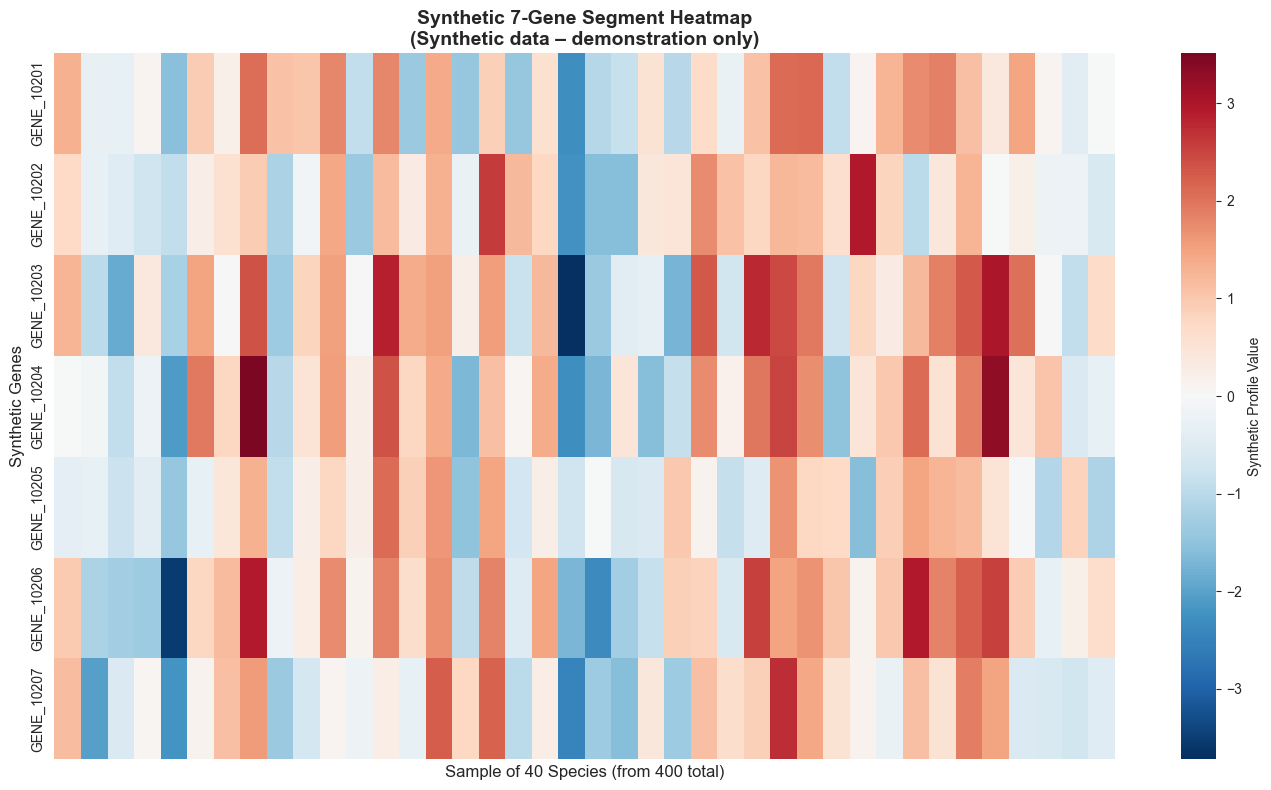

Saved: synthetic_segment_heatmap.png


In [10]:
plt.figure(figsize=(14, 8))

# Sample a subset of species for visualization (every 10th species)
viz_species = selected_species[::10]
df_segment_viz = df_segment[viz_species]

sns.heatmap(
    df_segment_viz,
    cmap='RdBu_r',
    center=0,
    cbar_kws={'label': 'Synthetic Profile Value'},
    xticklabels=False,
    yticklabels=True
)

plt.title('Synthetic 7-Gene Segment Heatmap\n(Synthetic data – demonstration only)', fontsize=14, fontweight='bold')
plt.xlabel(f'Sample of {len(viz_species)} Species (from {len(selected_species)} total)', fontsize=12)
plt.ylabel('Synthetic Genes', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'synthetic_segment_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: synthetic_segment_heatmap.png")


### 9.2 Consensus Profile Comparison


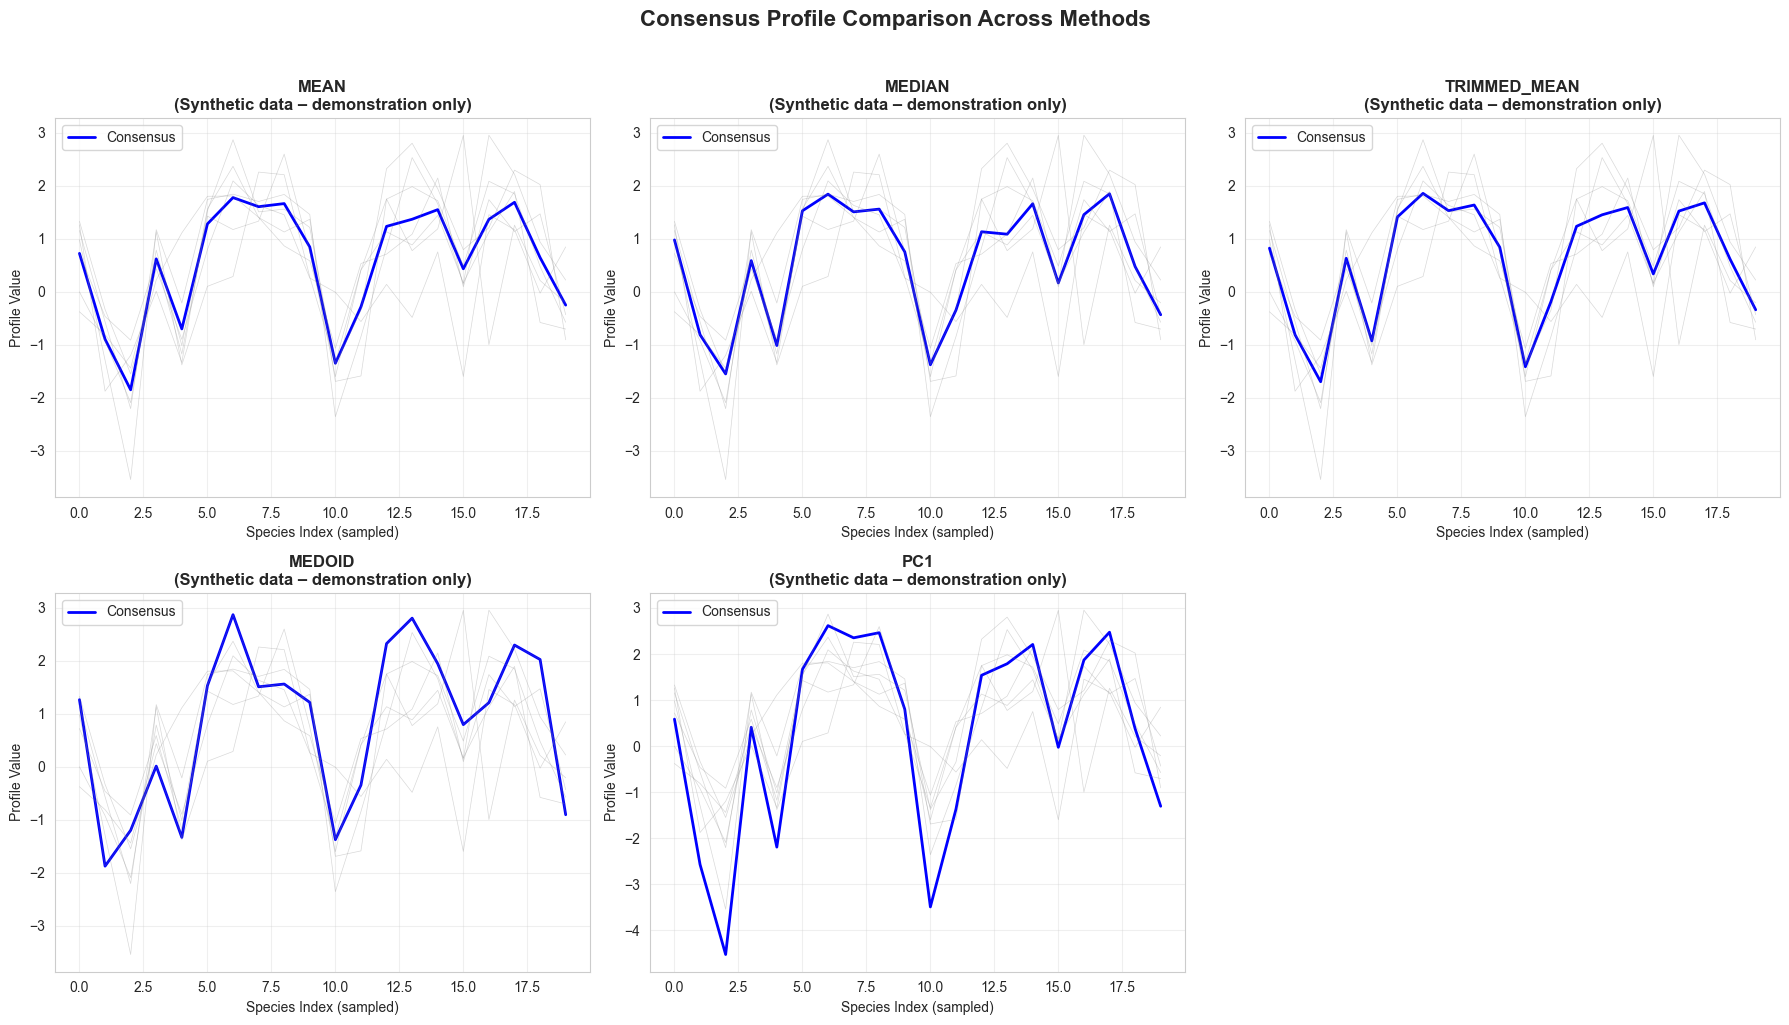

Saved: consensus_comparison.png


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# Sample species for visualization
viz_species_subset = selected_species[::20]  # Every 20th species

for idx, (cons_name, cons_vector) in enumerate(consensus_vectors.items()):
    ax = axes[idx]

    # Plot consensus profile
    ax.plot(range(len(viz_species_subset)), cons_vector[viz_species_subset].values, 'b-', linewidth=2, label='Consensus')

    # Overlay individual gene profiles (lighter)
    for gene_name in df_segment.index:
        ax.plot(range(len(viz_species_subset)), df_segment.loc[gene_name, viz_species_subset].values,
                'gray', alpha=0.3, linewidth=0.5)

    ax.set_title(f'{cons_name.upper()}\n(Synthetic data – demonstration only)', fontweight='bold')
    ax.set_xlabel('Species Index (sampled)')
    ax.set_ylabel('Profile Value')
    ax.grid(True, alpha=0.3)
    ax.legend()

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Consensus Profile Comparison Across Methods', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'consensus_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: consensus_comparison.png")


### 9.3 Coherence Boxplot


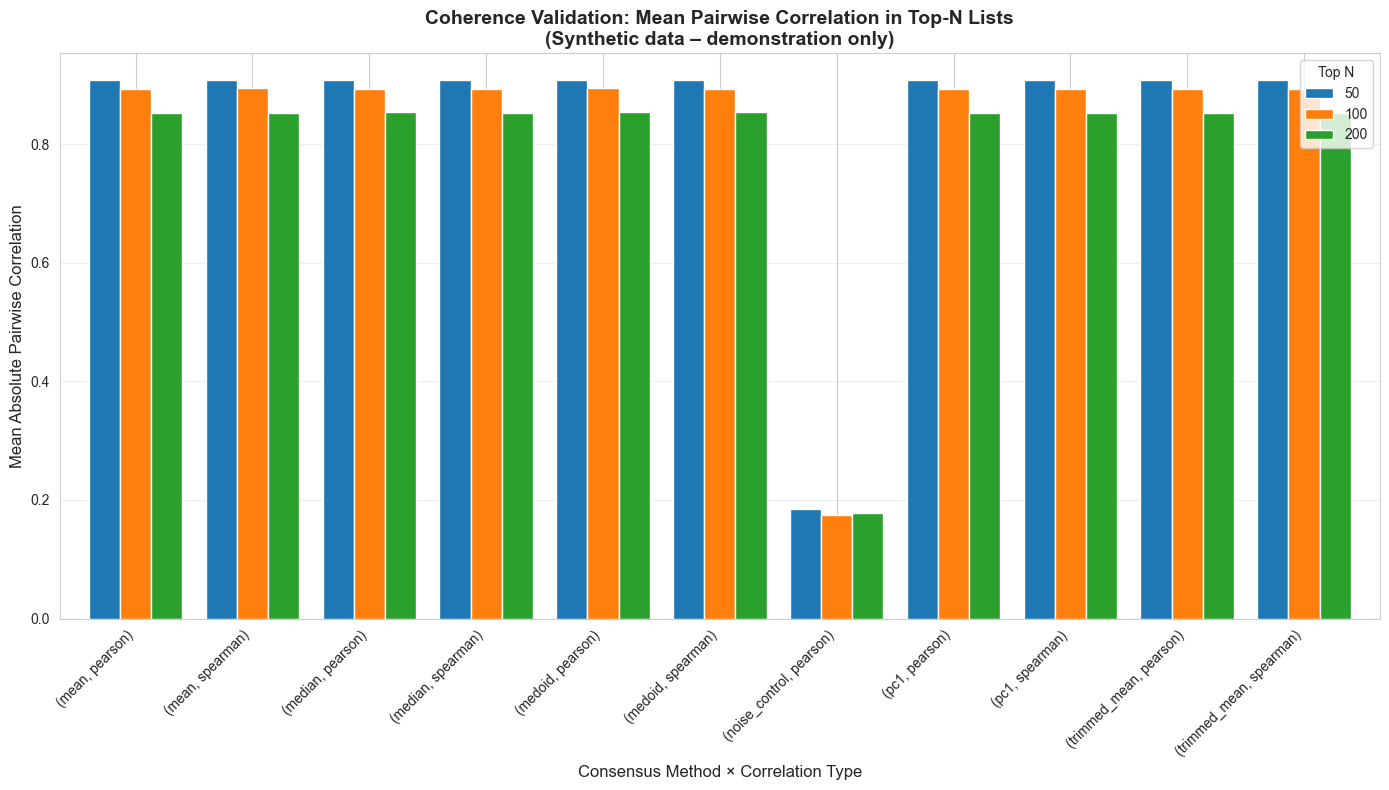

Saved: coherence_boxplot.png


In [12]:
# Prepare data for boxplot
coherence_data = []

for cons_name in consensus_vectors.keys():
    for corr_method in correlation_methods:
        for top_n in TOP_N_LIST:
            coherence = coherence_results[cons_name][corr_method][top_n]
            coherence_data.append({
                'Consensus Method': cons_name,
                'Correlation Type': corr_method,
                'Top N': top_n,
                'Coherence': coherence
            })

# Add noise control
for top_n in TOP_N_LIST:
    coherence_data.append({
        'Consensus Method': 'noise_control',
        'Correlation Type': 'pearson',
        'Top N': top_n,
        'Coherence': noise_coherence[top_n]
    })

df_coherence = pd.DataFrame(coherence_data)

# Create boxplot
plt.figure(figsize=(14, 8))

# Pivot for easier plotting
pivot_data = df_coherence.pivot_table(
    values='Coherence',
    index=['Consensus Method', 'Correlation Type'],
    columns='Top N'
)

pivot_data.plot(kind='bar', ax=plt.gca(), width=0.8)

plt.title('Coherence Validation: Mean Pairwise Correlation in Top-N Lists\n(Synthetic data – demonstration only)',
          fontsize=14, fontweight='bold')
plt.xlabel('Consensus Method × Correlation Type', fontsize=12)
plt.ylabel('Mean Absolute Pairwise Correlation', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Top N', title_fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'coherence_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: coherence_boxplot.png")


### 9.4 Correlation Distribution Comparison


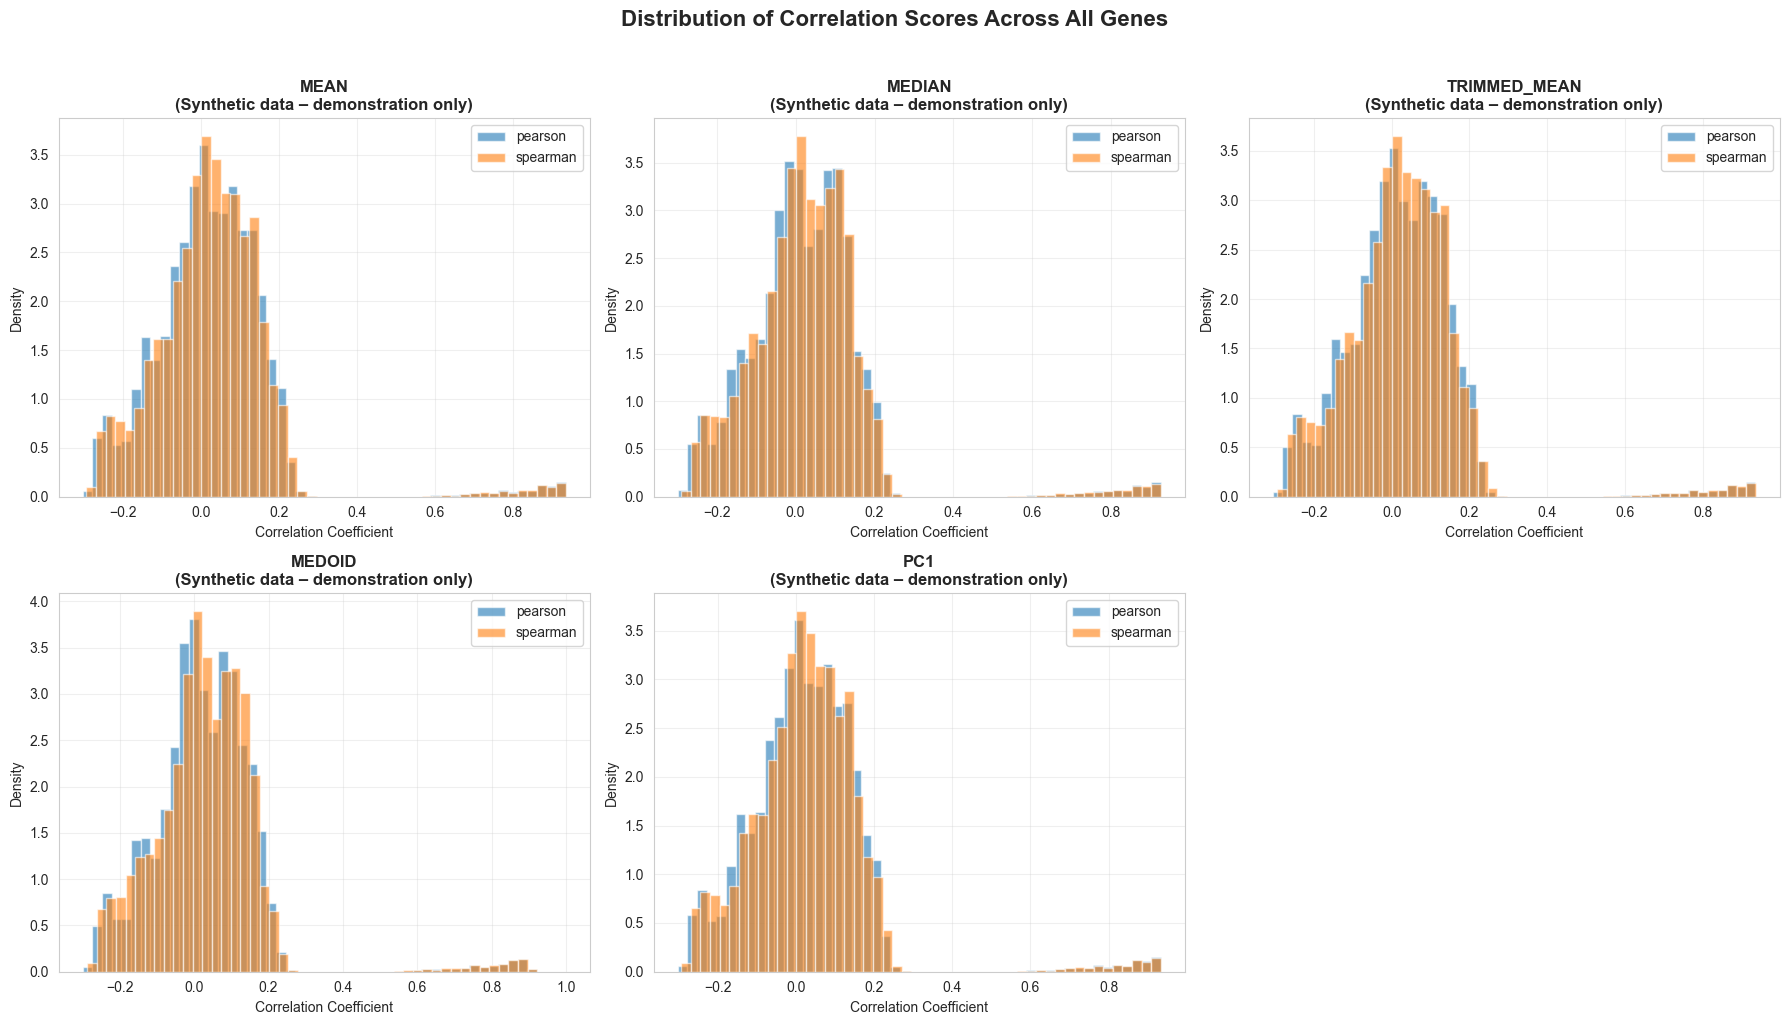

Saved: correlation_distributions.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (cons_name, cons_dict) in enumerate(all_correlations.items()):
    ax = axes[idx]

    for corr_method in correlation_methods:
        correlations = cons_dict[corr_method]
        ax.hist(correlations.values, bins=50, alpha=0.6, label=corr_method, density=True)

    ax.set_title(f'{cons_name.upper()}\n(Synthetic data – demonstration only)', fontweight='bold')
    ax.set_xlabel('Correlation Coefficient')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)

# Hide the last subplot
axes[5].axis('off')

plt.suptitle('Distribution of Correlation Scores Across All Genes', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'correlation_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: correlation_distributions.png")


### 9.5 Coherence Comparison: Signal vs. Noise


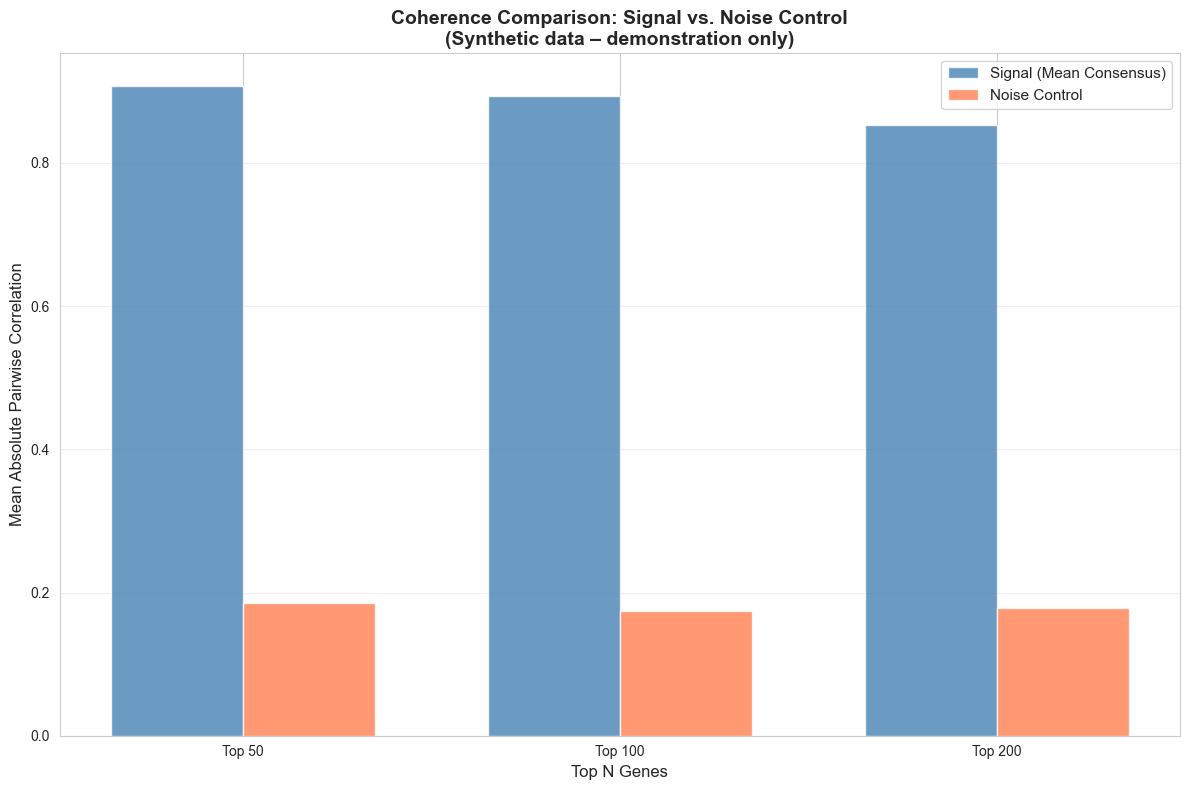

Saved: signal_vs_noise_coherence.png


In [14]:
plt.figure(figsize=(12, 8))

# Extract coherence values for one method (mean + pearson) as representative
signal_coherence = [coherence_results['mean']['pearson'][top_n] for top_n in TOP_N_LIST]
noise_coherence_vals = [noise_coherence[top_n] for top_n in TOP_N_LIST]

x_pos = np.arange(len(TOP_N_LIST))
width = 0.35

plt.bar(x_pos - width/2, signal_coherence, width, label='Signal (Mean Consensus)', alpha=0.8, color='steelblue')
plt.bar(x_pos + width/2, noise_coherence_vals, width, label='Noise Control', alpha=0.8, color='coral')

plt.xlabel('Top N Genes', fontsize=12)
plt.ylabel('Mean Absolute Pairwise Correlation', fontsize=12)
plt.title('Coherence Comparison: Signal vs. Noise Control\n(Synthetic data – demonstration only)',
          fontsize=14, fontweight='bold')
plt.xticks(x_pos, [f'Top {n}' for n in TOP_N_LIST])
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'signal_vs_noise_coherence.png'), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: signal_vs_noise_coherence.png")


## 10. Save Synthetic Data


In [15]:
# Save the segment
segment_path = '../data/synthetic_segments.csv'
df_segment.to_csv(segment_path)
print(f"Saved segment to: {segment_path}")

# Save a sample of the full matrix (first 1000 genes for file size)
sample_matrix_path = '../data/synthetic_full_matrix.csv'
df_full_matrix.iloc[:1000].to_csv(sample_matrix_path)
print(f"Saved sample full matrix (first 1000 genes) to: {sample_matrix_path}")

print("\nData export complete.")


Saved segment to: ../data/synthetic_segments.csv
Saved sample full matrix (first 1000 genes) to: ../data/synthetic_full_matrix.csv

Data export complete.


## Summary

This synthetic demonstration successfully:

1. ✅ Generated a full synthetic NPP matrix (20,000 genes × 1,900 species)
2. ✅ Selected a species subset (~400 species) using synthetic similarity rules
3. ✅ Extracted a 7-gene segment for consensus building
4. ✅ Generated 5 consensus profiles (mean, median, trimmed mean, medoid, PC1)
5. ✅ Performed correlation-based ranking over the species subset
6. ✅ Validated coherence of top-N lists
7. ✅ Demonstrated coherence collapse with negative control
8. ✅ Generated comprehensive visualizations

**All data and results are fully synthetic and for demonstration purposes only.**
